In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
import tensorflow as tf

# Vérifier si un GPU est disponible
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Restreindre la mémoire GPU pour éviter les crashes
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print("Le GPU est activé pour TensorFlow")
    except RuntimeError as e:
        print(e)


Le GPU est activé pour TensorFlow


In [ ]:
with open("/kaggle/input/shapenetpart-dataset/PartAnnotation/metadata.json") as json_file:
    metadata = json.load(json_file)

print(metadata)

{'Airplane': {'directory': '02691156', 'lables': ['wing', 'body', 'tail', 'engine'], 'colors': ['blue', 'green', 'red', 'pink']}, 'Bag': {'directory': '02773838', 'lables': ['handle', 'body'], 'colors': ['blue', 'green']}, 'Cap': {'directory': '02954340', 'lables': ['panels', 'peak'], 'colors': ['blue', 'green']}, 'Car': {'directory': '02958343', 'lables': ['wheel', 'hood', 'roof'], 'colors': ['blue', 'green', 'red']}, 'Chair': {'directory': '03001627', 'lables': ['leg', 'arm', 'back', 'seat'], 'colors': ['blue', 'green', 'red', 'pink']}, 'Earphone': {'directory': '03261776', 'lables': ['earphone', 'headband'], 'colors': ['blue', 'green']}, 'Guitar': {'directory': '03467517', 'lables': ['head', 'body', 'neck'], 'colors': ['blue', 'green', 'red']}, 'Knife': {'directory': '03624134', 'lables': ['handle', 'blade'], 'colors': ['blue', 'green']}, 'Lamp': {'directory': '03636649', 'lables': ['canopy', 'lampshade', 'base'], 'colors': ['blue', 'green', 'red']}, 'Laptop': {'directory': '0364280

In [ ]:
points_dir = "/kaggle/input/shapenetpart-dataset/PartAnnotation/{}/points".format(
    metadata["Airplane"]["directory"]
)
labels_dir = "/kaggle/input/shapenetpart-dataset/PartAnnotation/{}/points_label".format(
    metadata["Airplane"]["directory"]
)
LABELS = metadata["Airplane"]["lables"]
COLORS = metadata["Airplane"]["colors"]

VAL_SPLIT = 0.2
NUM_SAMPLE_POINTS = 1024
BATCH_SIZE = 32
EPOCHS = 60
INITIAL_LR = 1e-3

In [ ]:
point_clouds, test_point_clouds = [], []
point_cloud_labels, all_labels = [], []

points_files = glob(os.path.join(points_dir, "*.pts"))
for point_file in tqdm(points_files):
    point_cloud = np.loadtxt(point_file)
    if point_cloud.shape[0] < NUM_SAMPLE_POINTS:
        continue

    # Get the file-id of the current point cloud for parsing its
    # labels.
    file_id = point_file.split("/")[-1].split(".")[0]
    label_data, num_labels = {}, 0
    for label in LABELS:
        label_file = os.path.join(labels_dir, label, file_id + ".seg")
        if os.path.exists(label_file):
            label_data[label] = np.loadtxt(label_file).astype("float32")
            num_labels = len(label_data[label])

    # Point clouds having labels will be our training samples.
    try:
        label_map = ["none"] * num_labels
        for label in LABELS:
            for i, data in enumerate(label_data[label]):
                label_map[i] = label if data == 1 else label_map[i]
        label_data = [
            LABELS.index(label) if label != "none" else len(LABELS)
            for label in label_map
        ]
        # Apply one-hot encoding to the dense label representation.
        label_data = keras.utils.to_categorical(label_data, num_classes=len(LABELS) + 1)

        point_clouds.append(point_cloud)
        point_cloud_labels.append(label_data)
        all_labels.append(label_map)
    except KeyError:
        test_point_clouds.append(point_cloud)

100%|██████████| 4045/4045 [07:22<00:00,  9.15it/s]


In [ ]:
for _ in range(5):
    i = random.randint(0, len(point_clouds) - 1)
    print(f"point_clouds[{i}].shape:", point_clouds[0].shape)
    print(f"point_cloud_labels[{i}].shape:", point_cloud_labels[0].shape)
    for j in range(5):
        print(
            f"all_labels[{i}][{j}]:",
            all_labels[i][j],
            f"\tpoint_cloud_labels[{i}][{j}]:",
            point_cloud_labels[i][j],
            "\n",
        )

point_clouds[2942].shape: (2636, 3)
point_cloud_labels[2942].shape: (2636, 5)
all_labels[2942][0]: body 	point_cloud_labels[2942][0]: [0. 1. 0. 0. 0.] 

all_labels[2942][1]: engine 	point_cloud_labels[2942][1]: [0. 0. 0. 1. 0.] 

all_labels[2942][2]: engine 	point_cloud_labels[2942][2]: [0. 0. 0. 1. 0.] 

all_labels[2942][3]: wing 	point_cloud_labels[2942][3]: [1. 0. 0. 0. 0.] 

all_labels[2942][4]: engine 	point_cloud_labels[2942][4]: [0. 0. 0. 1. 0.] 

point_clouds[334].shape: (2636, 3)
point_cloud_labels[334].shape: (2636, 5)
all_labels[334][0]: engine 	point_cloud_labels[334][0]: [0. 0. 0. 1. 0.] 

all_labels[334][1]: tail 	point_cloud_labels[334][1]: [0. 0. 1. 0. 0.] 

all_labels[334][2]: engine 	point_cloud_labels[334][2]: [0. 0. 0. 1. 0.] 

all_labels[334][3]: wing 	point_cloud_labels[334][3]: [1. 0. 0. 0. 0.] 

all_labels[334][4]: wing 	point_cloud_labels[334][4]: [1. 0. 0. 0. 0.] 

point_clouds[209].shape: (2636, 3)
point_cloud_labels[209].shape: (2636, 5)
all_labels[209][0]: 

In [ ]:
import plotly.express as px
import pandas as pd

def visualize_data_interactive(point_cloud, labels):
    # Création du DataFrame
    df = pd.DataFrame(
        data={
            "x": point_cloud[:, 0],
            "y": point_cloud[:, 1],
            "z": point_cloud[:, 2],
            "label": labels,
        }
    )
    
    # Création du graphique interactif 3D
    fig = px.scatter_3d(df, x="x", y="y", z="z", color="label", labels={"label": "Classes"}, opacity=0.7)
    
    # Ajouter les noms de labels (classes)
    fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')), selector=dict(mode='markers'))
    
    # Titre et mise en forme
    fig.update_layout(
        title="Visualisation interactive des nuages de points",
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        legend_title="Labels"
    )
    
    # Affichage de la figure
    fig.show()

# Visualiser les nuages de points avec des étiquettes
visualize_data_interactive(point_clouds[0], all_labels[0])
visualize_data_interactive(point_clouds[300], all_labels[300])


In [ ]:
for index in tqdm(range(len(point_clouds))):
    current_point_cloud = point_clouds[index]
    current_label_cloud = point_cloud_labels[index]
    current_labels = all_labels[index]
    num_points = len(current_point_cloud)
    # Randomly sampling respective indices.
    sampled_indices = random.sample(list(range(num_points)), NUM_SAMPLE_POINTS)
    # Sampling points corresponding to sampled indices.
    sampled_point_cloud = np.array([current_point_cloud[i] for i in sampled_indices])
    # Sampling corresponding one-hot encoded labels.
    sampled_label_cloud = np.array([current_label_cloud[i] for i in sampled_indices])
    # Sampling corresponding labels for visualization.
    sampled_labels = np.array([current_labels[i] for i in sampled_indices])
    # Normalizing sampled point cloud.
    norm_point_cloud = sampled_point_cloud - np.mean(sampled_point_cloud, axis=0)
    norm_point_cloud /= np.max(np.linalg.norm(norm_point_cloud, axis=1))
    point_clouds[index] = norm_point_cloud
    point_cloud_labels[index] = sampled_label_cloud
    all_labels[index] = sampled_labels

100%|██████████| 3694/3694 [00:08<00:00, 431.17it/s]


In [ ]:
visualize_data_interactive(point_clouds[0], all_labels[0])
visualize_data_interactive(point_clouds[300], all_labels[300])

In [ ]:
def load_data(point_cloud_batch, label_cloud_batch):
    point_cloud_batch.set_shape([NUM_SAMPLE_POINTS, 3])
    label_cloud_batch.set_shape([NUM_SAMPLE_POINTS, len(LABELS) + 1])
    return point_cloud_batch, label_cloud_batch


def augment(point_cloud_batch, label_cloud_batch):
    noise = tf.random.uniform(
        tf.shape(label_cloud_batch), -0.005, 0.005, dtype=tf.float64
    )
    point_cloud_batch += noise[:, :, :3]
    return point_cloud_batch, label_cloud_batch


def generate_dataset(point_clouds, label_clouds, is_training=True):
    dataset = tf.data.Dataset.from_tensor_slices((point_clouds, label_clouds))
    dataset = dataset.shuffle(BATCH_SIZE * 100) if is_training else dataset
    dataset = dataset.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size=BATCH_SIZE)
    dataset = (
        dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        if is_training
        else dataset
    )
    return dataset


split_index = int(len(point_clouds) * (1 - VAL_SPLIT))
train_point_clouds = point_clouds[:split_index]
train_label_cloud = point_cloud_labels[:split_index]
total_training_examples = len(train_point_clouds)

val_point_clouds = point_clouds[split_index:]
val_label_cloud = point_cloud_labels[split_index:]

print("Num train point clouds:", len(train_point_clouds))
print("Num train point cloud labels:", len(train_label_cloud))
print("Num val point clouds:", len(val_point_clouds))
print("Num val point cloud labels:", len(val_label_cloud))

train_dataset = generate_dataset(train_point_clouds, train_label_cloud)
val_dataset = generate_dataset(val_point_clouds, val_label_cloud, is_training=False)

print("Train Dataset:", train_dataset)
print("Validation Dataset:", val_dataset)

Num train point clouds: 2955
Num train point cloud labels: 2955
Num val point clouds: 739
Num val point cloud labels: 739
Train Dataset: <_ParallelMapDataset element_spec=(TensorSpec(shape=(None, 1024, 3), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1024, 5), dtype=tf.float64, name=None))>
Validation Dataset: <_BatchDataset element_spec=(TensorSpec(shape=(None, 1024, 3), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1024, 5), dtype=tf.float64, name=None))>


Epoch 1/60
93/93 ━━━━━━━━━━━━━━━━━━━━ 56s 314ms/step - accuracy: 0.5090 - loss: 1.3124 - val_accuracy: 0.3004 - val_loss: 2.8657
Epoch 2/60
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.8133 - loss: 0.5346 - val_accuracy: 0.1923 - val_loss: 3.2417
Epoch 3/60
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.8354 - loss: 0.4667 - val_accuracy: 0.4113 - val_loss: 1.9571
Epoch 4/60
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - accuracy: 0.8428 - loss: 0.4432 - val_accuracy: 0.4378 - val_loss: 2.2544
Epoch 5/60
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - accuracy: 0.8468 - loss: 0.4311 - val_accuracy: 0.7220 - val_loss: 0.9658
Epoch 6/60
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.8520 - loss: 0.4093 - val_accuracy: 0.7254 - val_loss: 0.8277
Epoch 7/60
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.8530 - loss: 0.4044 - val_accuracy: 0.5335 - val_loss: 1.3383
Epoch 8/60
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 139ms/step - accuracy: 0.8568 - loss: 0.3907 - val_accu

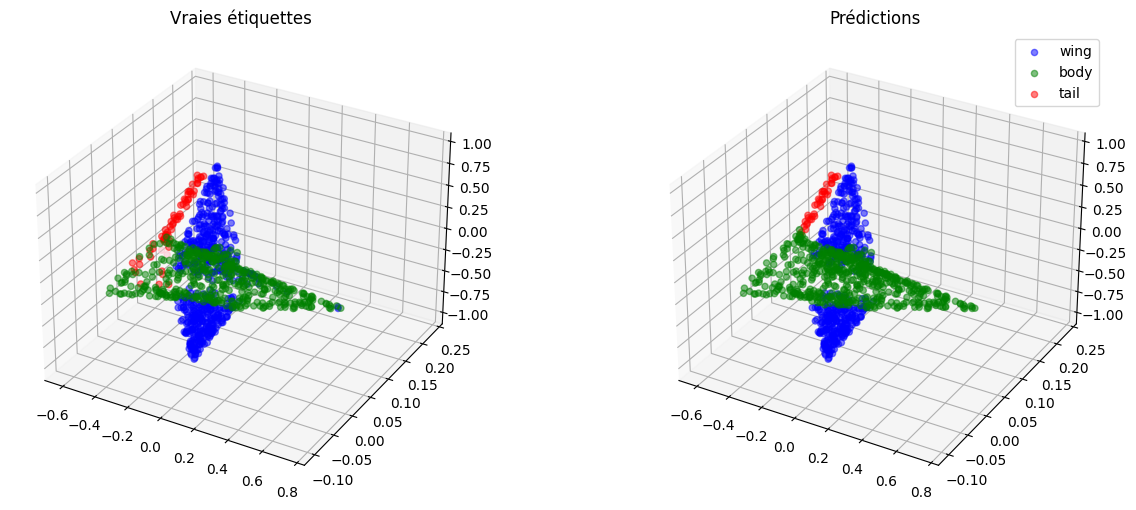

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


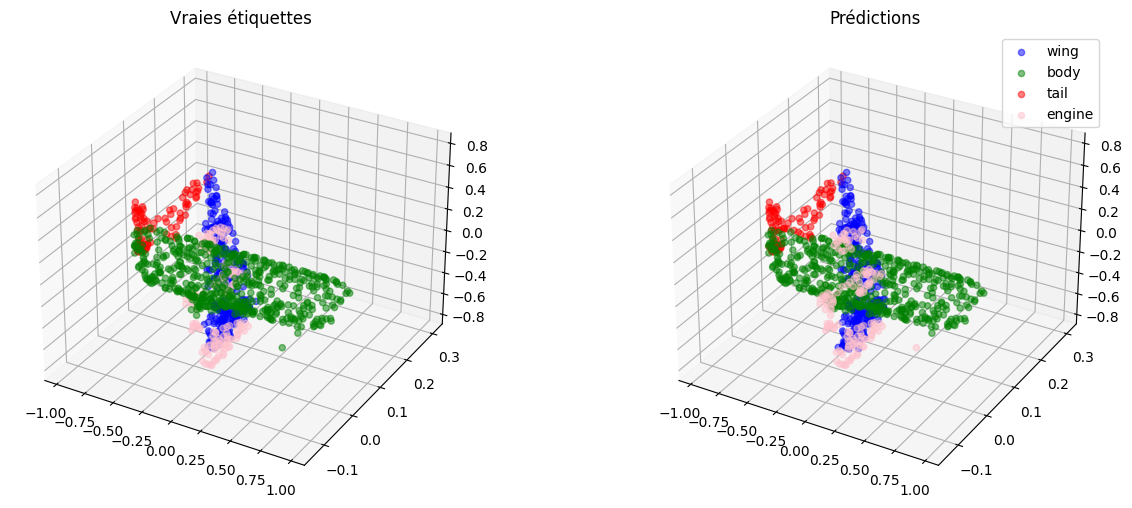

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


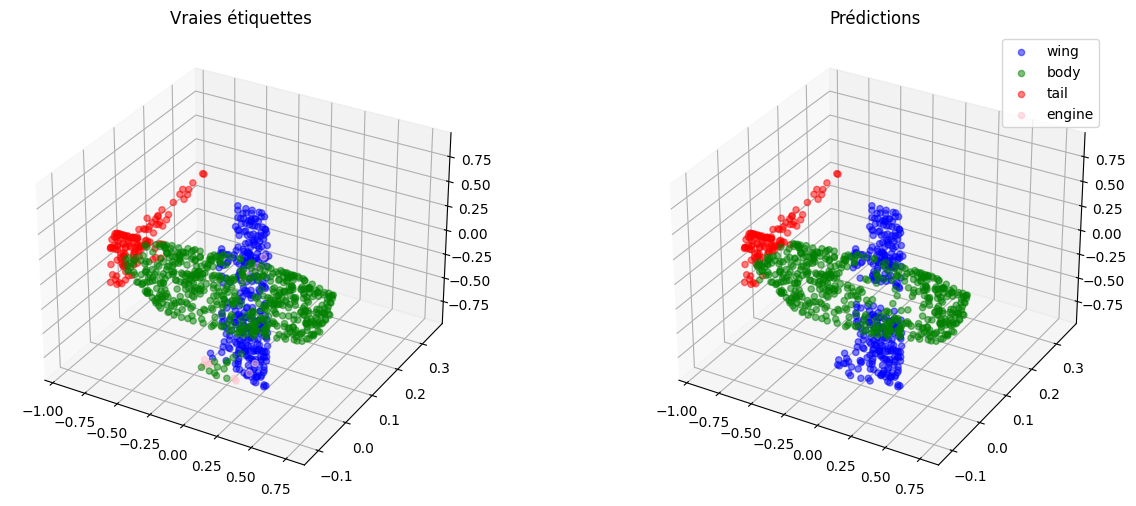

In [ ]:
# Définition des T-Nets pour les transformations
def get_transform_net(inputs, num_features, initial_bias):
    x = layers.Conv1D(64, 1, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 1, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(1024, 1, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(
        num_features * num_features,
        kernel_initializer='zeros',
        bias_initializer=keras.initializers.Constant(initial_bias)
    )(x)
    x = layers.Reshape((num_features, num_features))(x)
    return x

# Architecture du modèle
def get_segmentation_model(num_classes):
    inputs = keras.Input(shape=(NUM_SAMPLE_POINTS, 3))
    
    # Transformation d'entrée
    input_transform = get_transform_net(inputs, 3, np.eye(3).flatten())
    transformed = layers.Dot(axes=(2, 1))([inputs, input_transform])
    
    # Extraction de caractéristiques
    x = layers.Conv1D(64, 1, activation='relu')(transformed)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 1, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    # Transformation des caractéristiques
    feature_transform = get_transform_net(x, 64, np.eye(64).flatten())
    transformed_features = layers.Dot(axes=(2, 1))([x, feature_transform])
    
    # Traitement supplémentaire
    x = layers.Conv1D(64, 1, activation='relu')(transformed_features)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 1, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    local_features = x
    
    # Caractéristiques globales
    x = layers.Conv1D(1024, 1, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    global_features = layers.GlobalMaxPooling1D()(x)
    global_features = layers.RepeatVector(NUM_SAMPLE_POINTS)(global_features)
    
    # Fusion des caractéristiques
    concatenated = layers.concatenate([local_features, global_features])
    
    # Couches finales
    x = layers.Conv1D(512, 1, activation='relu')(concatenated)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(256, 1, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(128, 1, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    # Sortie
    outputs = layers.Conv1D(num_classes, 1, activation='softmax')(x)
    
    return keras.Model(inputs=inputs, outputs=outputs)

# Compilation du modèle
model = get_segmentation_model(num_classes=len(LABELS)+1)
model.compile(
    optimizer=keras.optimizers.Adam(INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
with tf.device('/GPU:0'):
# Entraînement
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE
    )

# Visualisation des résultats
def visualize_prediction(point_cloud, true_labels, pred_labels):
    fig = plt.figure(figsize=(15, 6))
    
    # Vraies étiquettes
    ax1 = fig.add_subplot(121, projection='3d')
    df_true = pd.DataFrame({
        'x': point_cloud[:,0], 
        'y': point_cloud[:,1], 
        'z': point_cloud[:,2], 
        'label': true_labels
    })
    for idx, label in enumerate(LABELS):
        c_df = df_true[df_true['label'] == label]
        if len(c_df) > 0:
            ax1.scatter(c_df['x'], c_df['y'], c_df['z'], c=COLORS[idx], label=label, alpha=0.5)
    ax1.set_title('Vraies étiquettes')
    
    # Étiquettes prédites
    ax2 = fig.add_subplot(122, projection='3d')
    df_pred = pd.DataFrame({
        'x': point_cloud[:,0], 
        'y': point_cloud[:,1], 
        'z': point_cloud[:,2], 
        'label': pred_labels
    })
    for idx, label in enumerate(LABELS):
        c_df = df_pred[df_pred['label'] == label]
        if len(c_df) > 0:
            ax2.scatter(c_df['x'], c_df['y'], c_df['z'], c=COLORS[idx], label=label, alpha=0.5)
    ax2.set_title('Prédictions')
    
    plt.legend()
    plt.show()

# Prédiction sur des exemples de validation
for _ in range(3):
    idx = np.random.randint(len(val_point_clouds))
    pc = val_point_clouds[idx]
    label = val_label_cloud[idx]
    
    pred = model.predict(pc[np.newaxis, ...])[0]
    pred_labels = [LABELS[np.argmax(p)] if np.argmax(p) < len(LABELS) else 'none' for p in pred]
    true_labels = [LABELS[np.argmax(l)] if np.argmax(l) < len(LABELS) else 'none' for l in label]
    
    visualize_prediction(pc, true_labels, pred_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


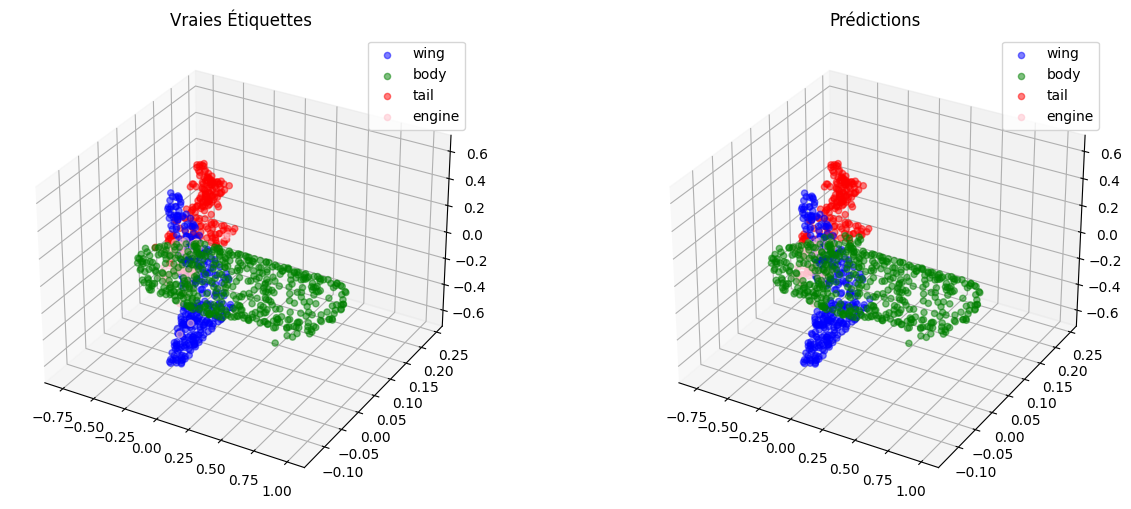

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


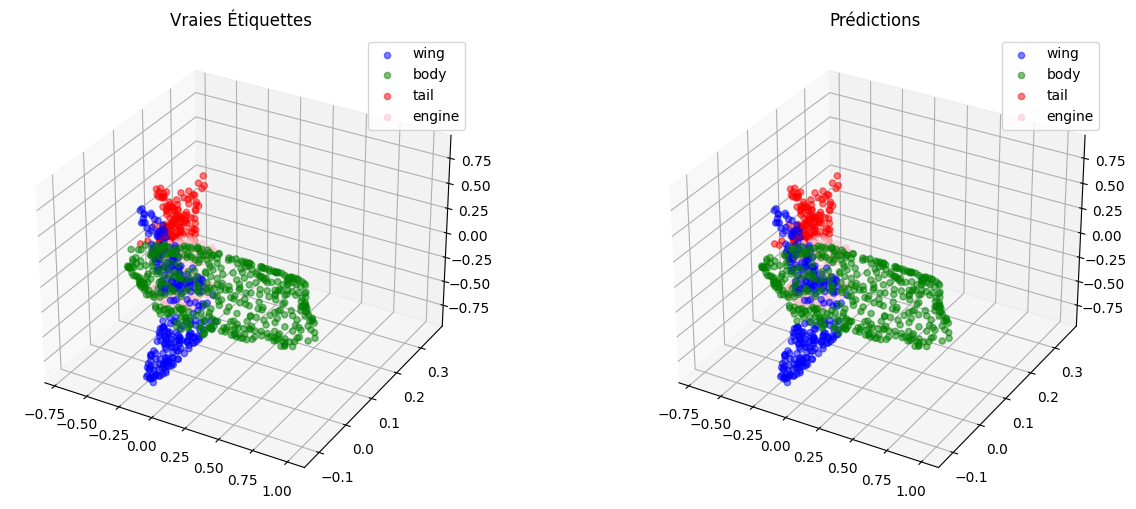

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


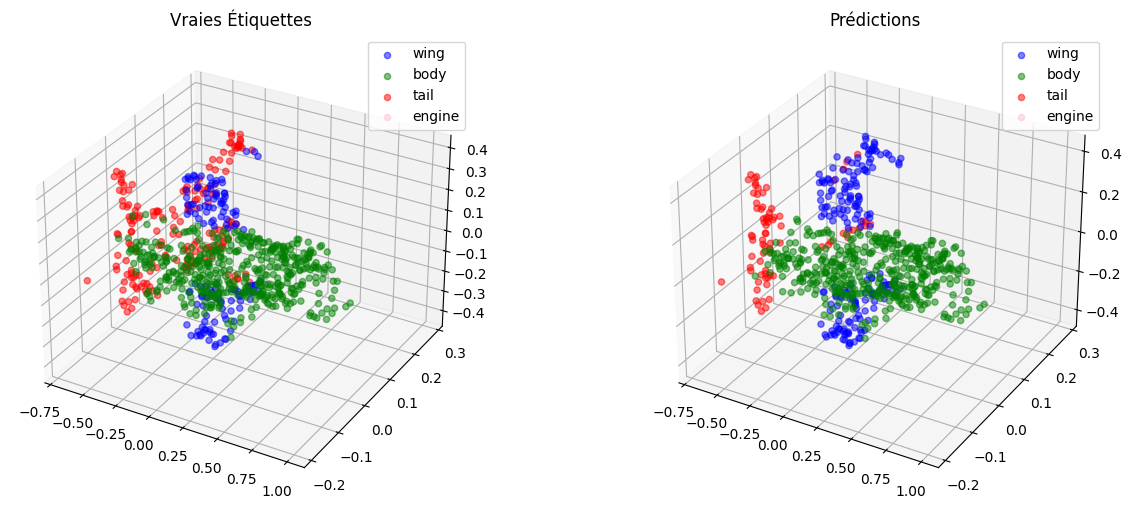

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def visualize_prediction_combined(point_cloud, true_labels, pred_labels):
    # Créer un DataFrame pour les vraies étiquettes
    df_true = pd.DataFrame({
        'x': point_cloud[:, 0], 
        'y': point_cloud[:, 1], 
        'z': point_cloud[:, 2], 
        'label': true_labels
    })
    
    # Créer un DataFrame pour les prédictions
    df_pred = pd.DataFrame({
        'x': point_cloud[:, 0], 
        'y': point_cloud[:, 1], 
        'z': point_cloud[:, 2], 
        'label': pred_labels
    })
    
    # Créer la figure avec deux sous-graphes
    fig = plt.figure(figsize=(15, 6))
    
    # Sous-graphe pour les vraies étiquettes
    ax1 = fig.add_subplot(121, projection='3d')
    for idx, label in enumerate(LABELS):
        c_df = df_true[df_true['label'] == label]
        ax1.scatter(c_df['x'], c_df['y'], c_df['z'], c=COLORS[idx], label=label, alpha=0.5)
    ax1.set_title('Vraies Étiquettes')
    
    # Sous-graphe pour les prédictions
    ax2 = fig.add_subplot(122, projection='3d')
    for idx, label in enumerate(LABELS):
        c_df = df_pred[df_pred['label'] == label]
        ax2.scatter(c_df['x'], c_df['y'], c_df['z'], c=COLORS[idx], label=label, alpha=0.5)
    ax2.set_title('Prédictions')
    
    # Affichage de la légende
    ax1.legend()
    ax2.legend()
    
    # Affichage de la figure
    plt.show()

# Prédiction sur des exemples de validation
for _ in range(3):
    idx = np.random.randint(len(val_point_clouds))
    pc = val_point_clouds[idx]
    label = val_label_cloud[idx]
    
    # Effectuer la prédiction
    pred = model.predict(pc[np.newaxis, ...])[0]
    pred_labels = [LABELS[np.argmax(p)] if np.argmax(p) < len(LABELS) else 'none' for p in pred]
    true_labels = [LABELS[np.argmax(l)] if np.argmax(l) < len(LABELS) else 'none' for l in label]
    
    # Visualiser les résultats
    visualize_prediction_combined(pc, true_labels, pred_labels)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step


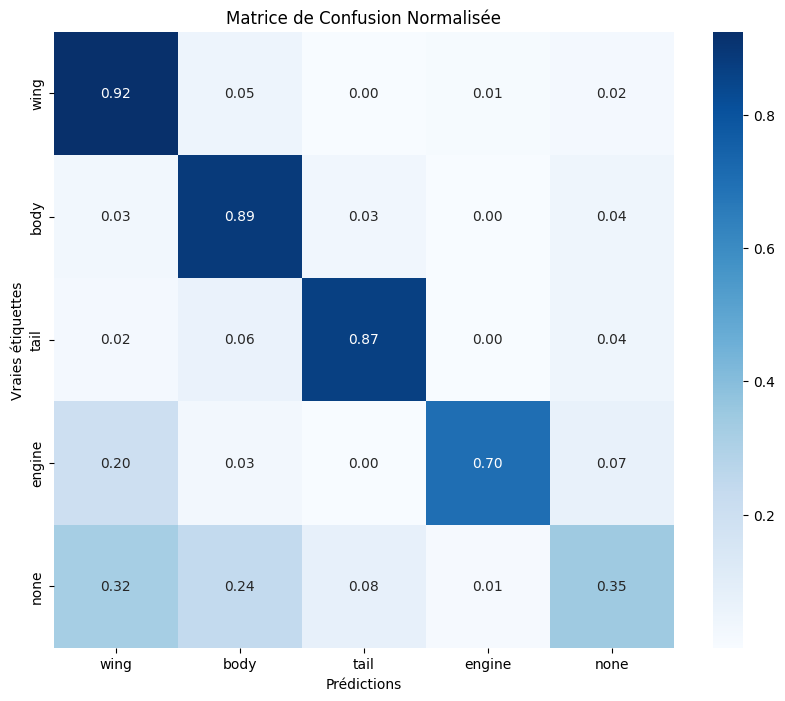

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prédictions sur l'ensemble de validation
y_true = []
y_pred = []

for point_cloud, labels in val_dataset:
    preds = model.predict(point_cloud)
    
    # Conversion des one-hot vectors en indices de classe
    y_true.extend(np.argmax(labels.numpy(), axis=-1).flatten())
    y_pred.extend(np.argmax(preds, axis=-1).flatten())

# Matrice de confusion brute
conf_matrix = confusion_matrix(y_true, y_pred, labels=range(len(LABELS) + 1))

# 🔹 Normalisation de la matrice de confusion
conf_matrix = conf_matrix.astype("float") / conf_matrix.sum(axis=1, keepdims=True)

# Visualisation
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LABELS + ["none"], yticklabels=LABELS + ["none"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies étiquettes")
plt.title("Matrice de Confusion Normalisée")
plt.show()


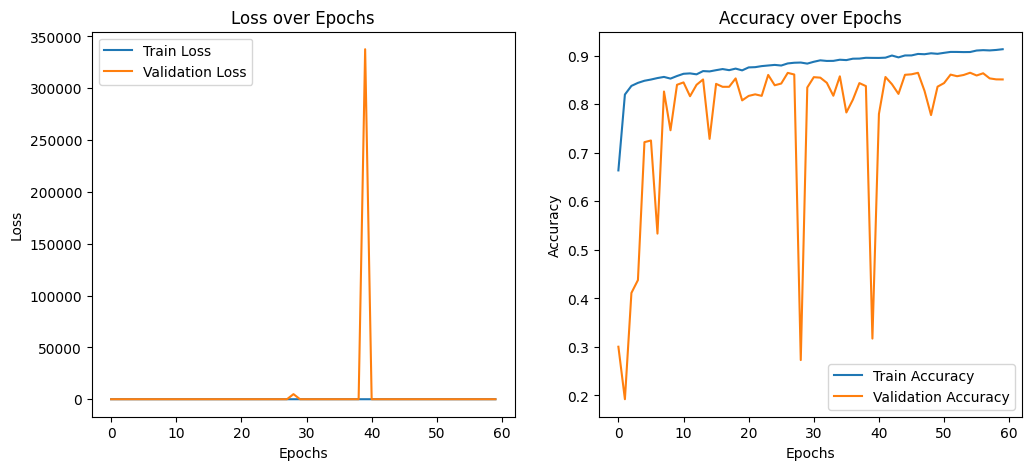

In [ ]:
# Tracer les courbes d'apprentissage
plt.figure(figsize=(12, 5))

# Courbe de la perte
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Courbe de la précision
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Rapport de classification
class_report = classification_report(
    y_true, y_pred, target_names=LABELS + ["none"], digits=4
)
print("Rapport de Classification :\n", class_report)

Rapport de Classification :
               precision    recall  f1-score   support

        wing     0.8471    0.9242    0.8840    227344
        body     0.9122    0.8874    0.8996    341652
        tail     0.8334    0.8696    0.8511     90186
      engine     0.9126    0.7020    0.7936     52453
        none     0.3720    0.3454    0.3582     45101

    accuracy                         0.8512    756736
   macro avg     0.7755    0.7457    0.7573    756736
weighted avg     0.8511    0.8512    0.8495    756736



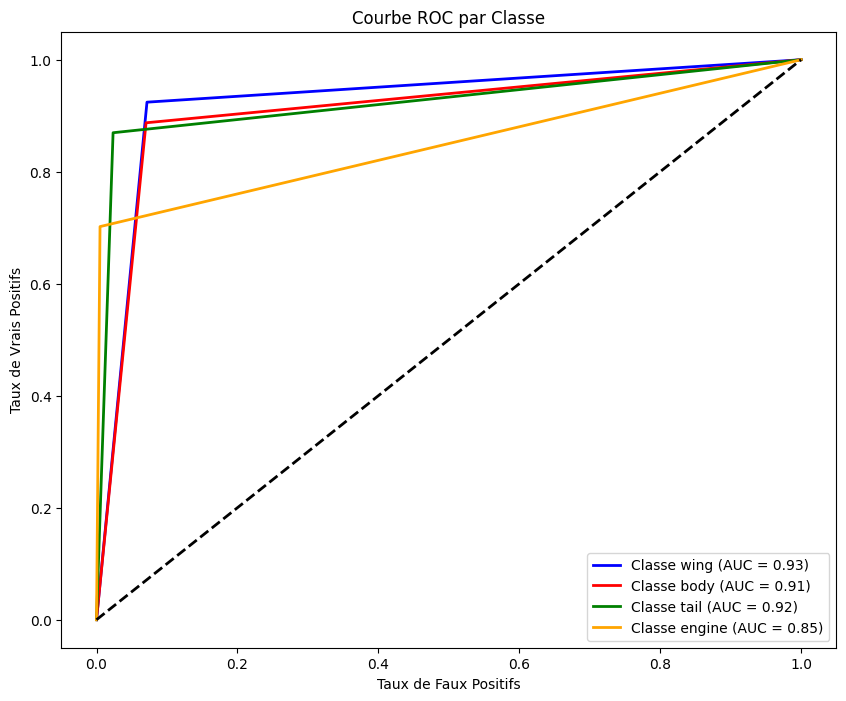

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Exclure la classe "none"
NUM_CLASSES = len(LABELS)  # Nombre exact de classes sans "none"

# Binariser les labels
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
y_pred_bin = label_binarize(y_pred, classes=range(NUM_CLASSES))

# Calculer la courbe ROC pour chaque classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Tracer la courbe ROC
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {LABELS[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC par Classe')
plt.legend(loc="lower right")
plt.show()


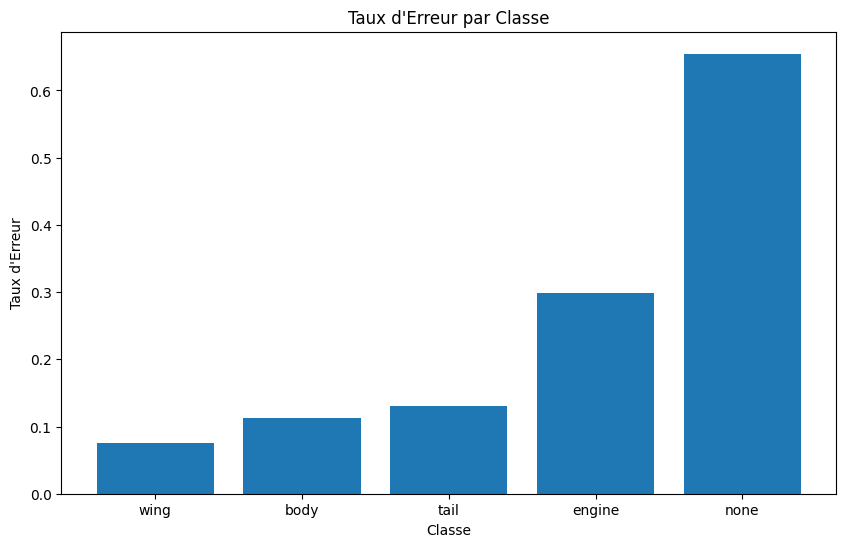

In [ ]:
error_rates = []
for i in range(len(LABELS) + 1):
    class_indices = np.where(np.array(y_true) == i)[0]
    if len(class_indices) > 0:
        error_rate = 1 - np.sum(np.array(y_true)[class_indices] == np.array(y_pred)[class_indices]) / len(class_indices)
        error_rates.append(error_rate)
    else:
        error_rates.append(0)

# Visualisation
plt.figure(figsize=(10, 6))
plt.bar(range(len(LABELS) + 1), error_rates, tick_label=LABELS + ["none"])
plt.xlabel('Classe')
plt.ylabel('Taux d\'Erreur')
plt.title('Taux d\'Erreur par Classe')
plt.show()